In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stats
import scipy.stats as stats
from scipy.stats import skew, kurtosis, anderson, shapiro


In [3]:
df = pd.read_csv('customer_churn.csv')
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
df.shape

(64374, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  str  
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  str  
 8   Contract Length    64374 non-null  str  
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(9), str(3)
memory usage: 5.9 MB


In [6]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df1 = df.copy()
df1.drop(columns=['CustomerID'], inplace=True)

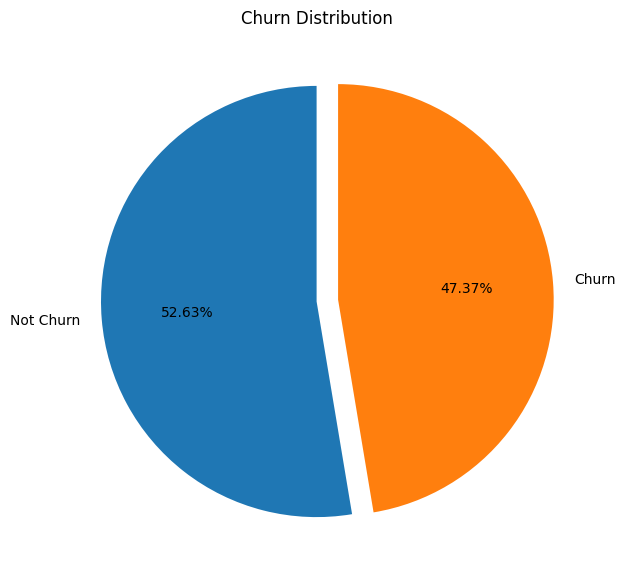

In [9]:
import matplotlib.pyplot as plt

counts = df1['Churn'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    counts,
    labels=['Not Churn', 'Churn'],
    autopct='%1.2f%%',
    startangle=90,
    explode=(0, 0.1)
)

plt.title('Churn Distribution')

plt.show()

In [10]:
counts/len(df1)*100

Churn
0    52.631497
1    47.368503
Name: count, dtype: float64

In [11]:
num_col = df1.select_dtypes(include=np.number).columns
num_col.shape

(8,)

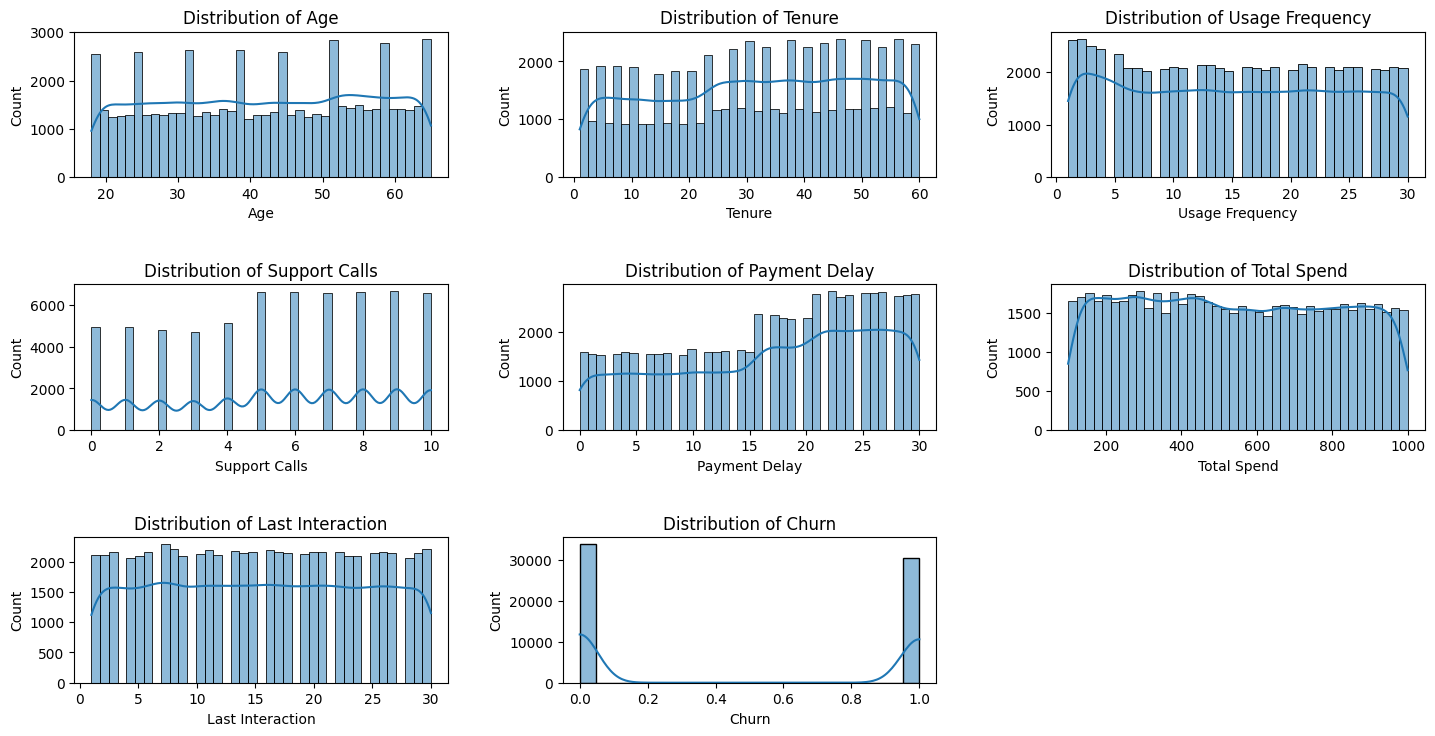

In [12]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(num_col,1):
    plt.subplot(3,3,i)
    sns.histplot(df1[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout(pad=3)
plt.show()

In [13]:
df[num_col].skew()

Age                -0.040894
Tenure             -0.126056
Usage Frequency     0.037543
Support Calls      -0.192854
Payment Delay      -0.350714
Total Spend         0.047746
Last Interaction    0.005112
Churn               0.105408
dtype: float64

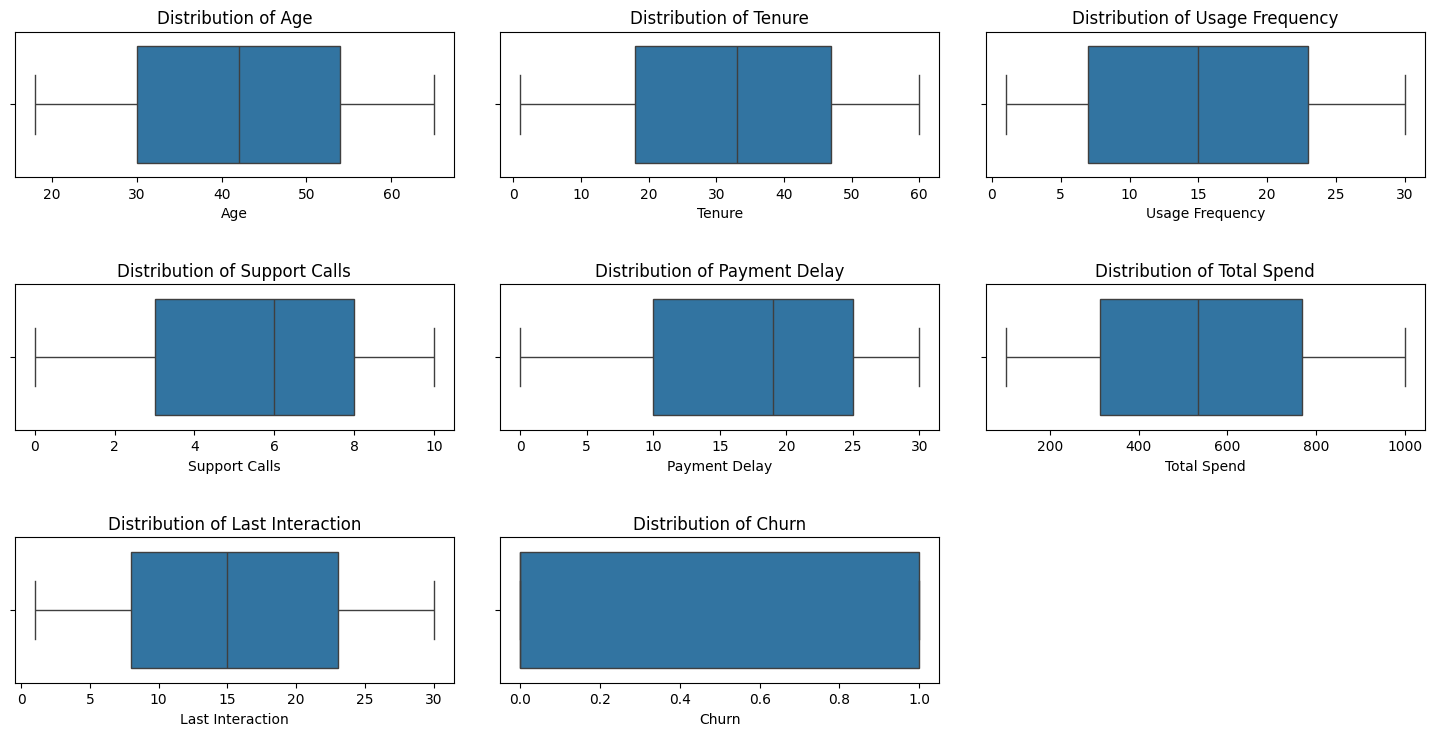

In [14]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(num_col,1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df1[col])
    plt.title(f"Distribution of {col}")
plt.tight_layout(pad=3)
plt.show()

In [15]:
df1.describe(include=np.number)

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


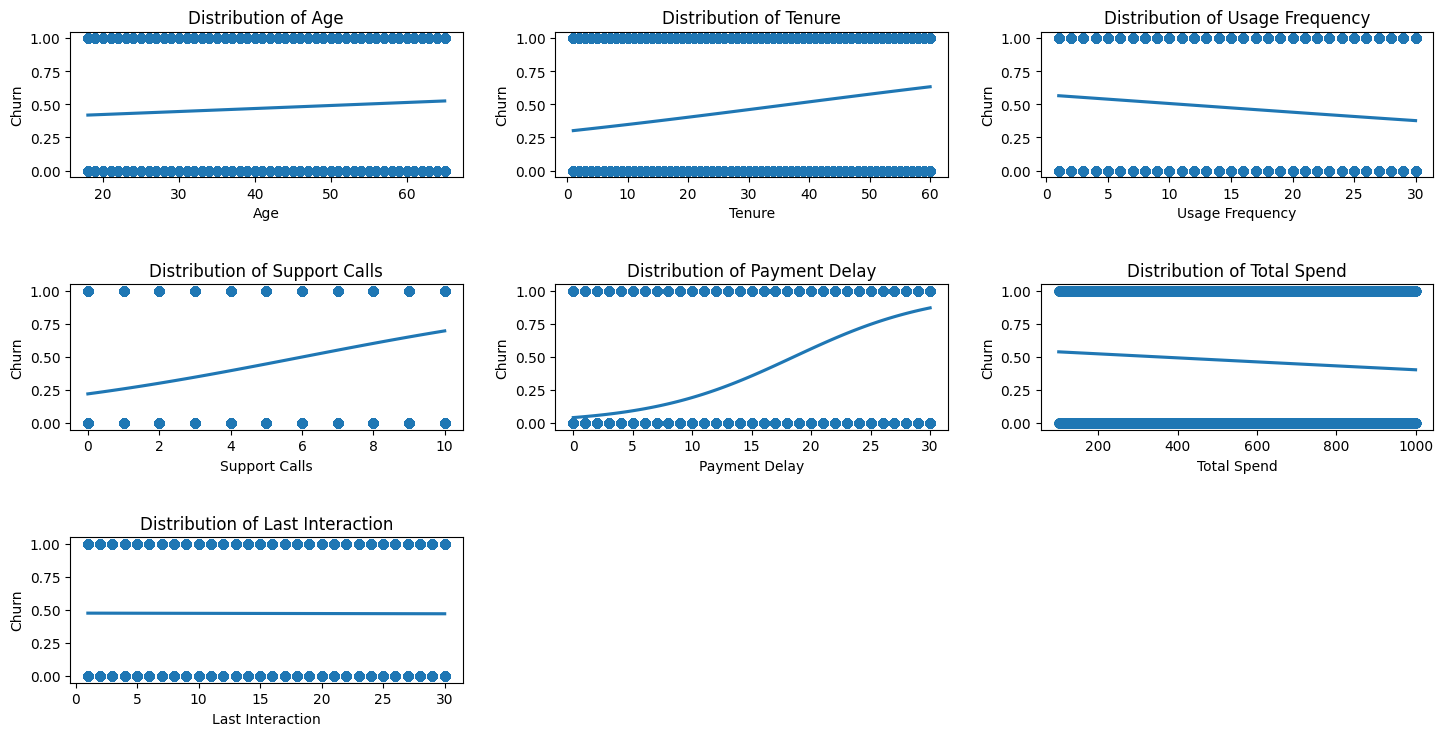

In [16]:
target = 'Churn'

num_col_reg = df1.select_dtypes(include=np.number).columns
num_col_reg = num_col_reg.drop(target)

plt.figure(figsize=(15, 8))

for i, col in enumerate(num_col_reg,1):
    plt.subplot(3,3,i)
    sns.regplot(x=df1[col], y=df1[target], logistic=True, ci=None)
    plt.title(f"Distribution of {col}")
plt.tight_layout(pad=3)
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

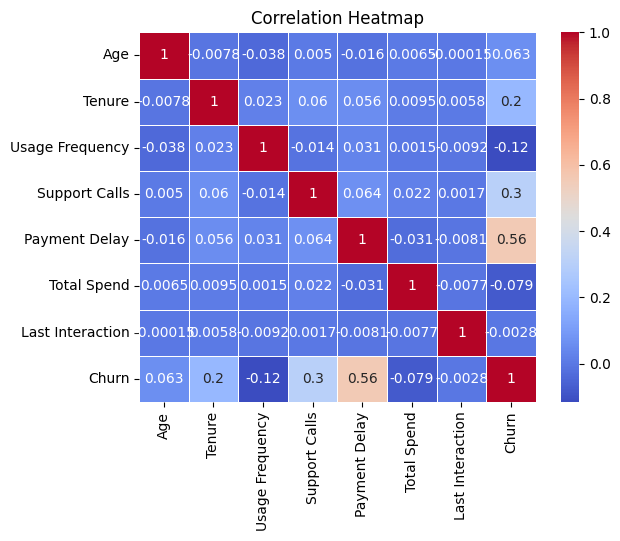

In [17]:
sns.heatmap(df1[num_col].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')

In [18]:
corr = df1[num_col].corr()['Churn'].sort_values(ascending=False)
corr

Churn               1.000000
Payment Delay       0.557386
Support Calls       0.304631
Tenure              0.195327
Age                 0.063457
Last Interaction   -0.002818
Total Spend        -0.078867
Usage Frequency    -0.115098
Name: Churn, dtype: float64

In [21]:
from scipy.stats import pearsonr as pearson
from scipy.stats import spearmanr as spearman

# ==========================================
# STORE RESULTS
# ==========================================
results = []

# ==========================================
# LOOP ALL FEATURES
# ==========================================
for feature in num_col_reg:
    
    # feature data
    x = df1[feature]
    y = df1[target]
    
    # Pearson
    pearson_corr, pearson_p = pearson(x, y)
    
    # Spearman
    spearman_corr, spearman_p = spearman(x, y)
    
    # save results
    results.append({
        'Feature': feature,
        
        'Pearson Corr': pearson_corr,
        
        'Spearman Corr': spearman_corr,
        
    })

# ==========================================
# CREATE RESULT DATAFRAME
# ==========================================
corr_df1 = pd.DataFrame(results)

# ==========================================
# SORT BY SPEARMAN
# ==========================================
corr_df1 = corr_df1.sort_values(
    by='Spearman Corr',
    ascending=False
)

# ==========================================
# DISPLAY RESULT
# ==========================================
print(corr_df1)

            Feature  Pearson Corr  Spearman Corr
4     Payment Delay      0.557386       0.553713
3     Support Calls      0.304631       0.299143
1            Tenure      0.195327       0.192630
0               Age      0.063457       0.063809
6  Last Interaction     -0.002818      -0.002828
5       Total Spend     -0.078867      -0.078916
2   Usage Frequency     -0.115098      -0.117157


In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# pilih numerical columns sahaja
vif = df1[['Tenure',
         'Usage Frequency',
         'Support Calls',
         'Payment Delay',
        ]]

# create dataframe VIF
vif_data = pd.DataFrame()

vif_data['Feature'] = vif.columns

vif_data['VIF'] = [
    variance_inflation_factor(vif.values, i)
    for i in range(vif.shape[1])
]

print(vif_data)

           Feature       VIF
0           Tenure  3.584711
1  Usage Frequency  3.109894
2    Support Calls  3.289567
3    Payment Delay  3.725266


In [23]:
cat_col = df1.select_dtypes(include='object').columns
cat_col.shape

C:\Users\Mohd Zuhairi\AppData\Local\Temp\ipykernel_25496\2260585021.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df1.select_dtypes(include='object').columns


(3,)

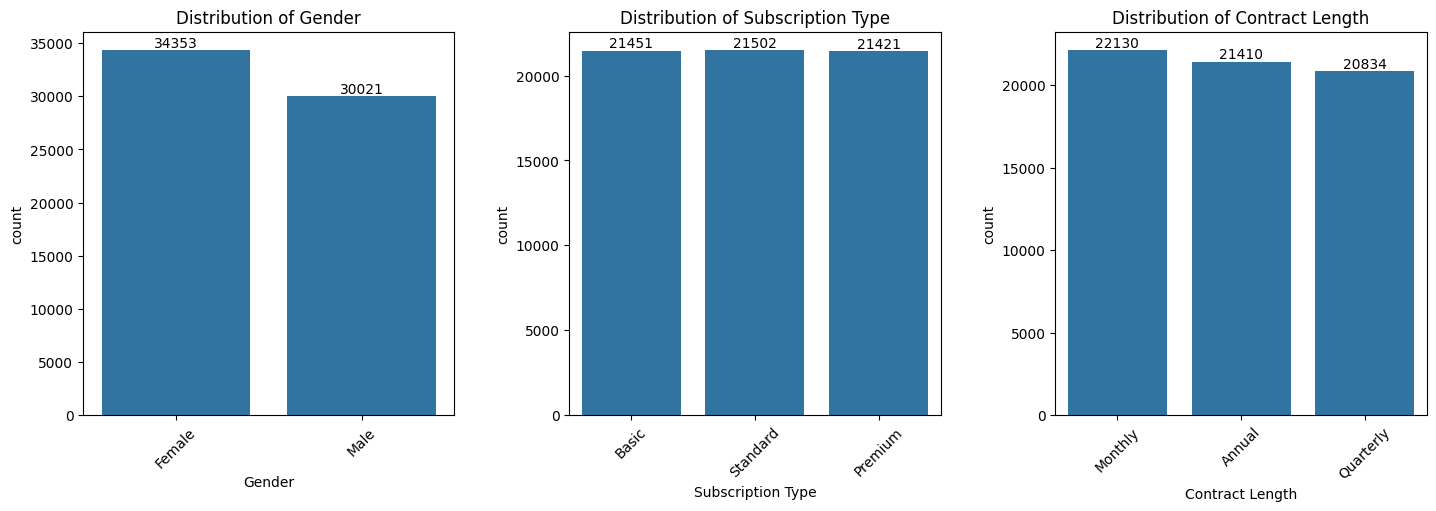

In [24]:
plt.figure(figsize=(15,10))

for i, col in enumerate(cat_col, 1):
    
    plt.subplot(2, 3, i)

    ax = sns.countplot(data=df1, x=col)

    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

    # tambah label atas bar
    for p in ax.patches:
        
        ax.annotate(
            f'{int(p.get_height())}',

            (p.get_x() + p.get_width() / 2,
             p.get_height()),

            ha='center',
            va='bottom',
            fontsize=10
        )

plt.tight_layout(pad=3)

plt.show()

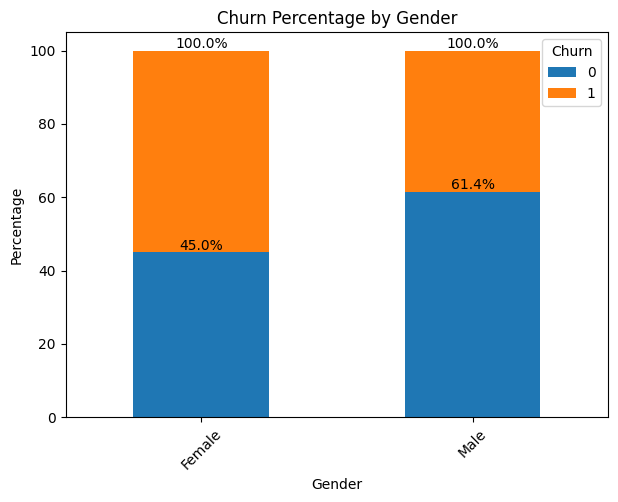

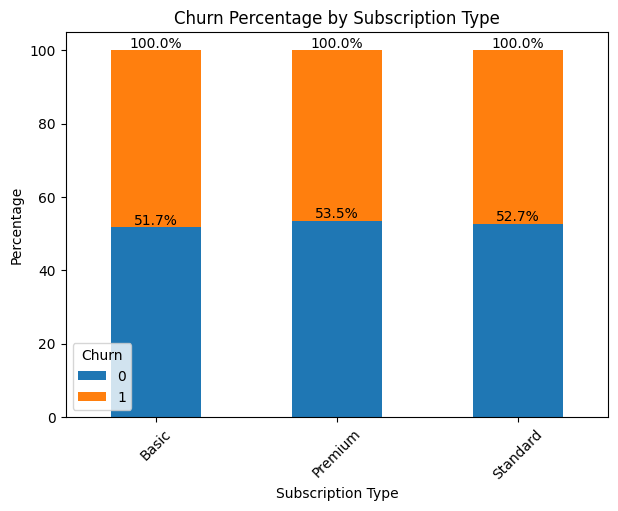

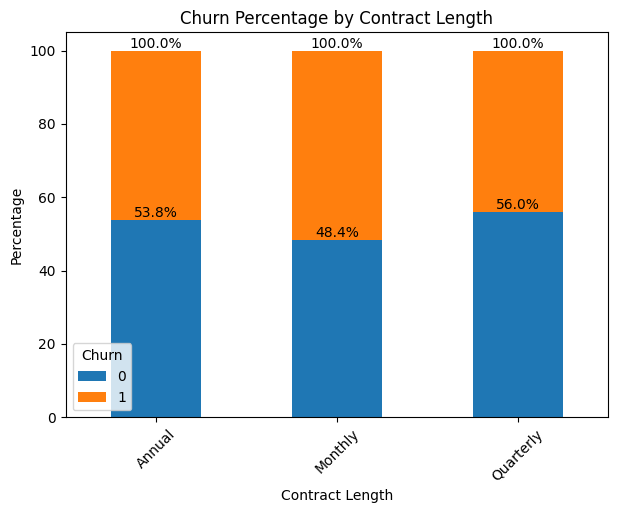

In [25]:
target = 'Churn'

for col in cat_col:

    churn_rate = pd.crosstab(
        df1[col],
        df1[target],
        normalize='index'
    ) * 100

    ax = churn_rate.plot(
        kind='bar',
        stacked=True,
        figsize=(7,5)
    )

    plt.title(f'Churn Percentage by {col}')

    plt.ylabel('Percentage')

    plt.xticks(rotation=45)

    # label percentage atas bar
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f%%'
        )

    plt.show()

In [26]:
from scipy.stats import chi2_contingency

target = 'Churn'

for col in cat_col:

    # contingency table
    table = pd.crosstab(df1[col], df1[target])

    # chi-square test
    chi2, p, dof, expected = chi2_contingency(table)

    print(f'\n===== {col} =====')

    print(f'Chi-Square Statistic : {chi2:.4f}')
    print(f'P-Value              : {p:.4f}')

    # interpretation
    if p < 0.05:
        print('Result : Significant Relationship')
    else:
        print('Result : No Significant Relationship')


===== Gender =====
Chi-Square Statistic : 1742.3455
P-Value              : 0.0000
Result : Significant Relationship

===== Subscription Type =====
Chi-Square Statistic : 13.6559
P-Value              : 0.0011
Result : Significant Relationship

===== Contract Length =====
Chi-Square Statistic : 263.1141
P-Value              : 0.0000
Result : Significant Relationship


In [27]:
from scipy.stats import chi2_contingency

for col in cat_col:

    # contingency table
    table = pd.crosstab(
        df1[col],
        df1[target]
    )

    # chi-square
    chi2, p, dof, expected = chi2_contingency(table)

    # sample size
    n = table.sum().sum()

    # minimum dimension
    min_dim = min(table.shape) - 1

    # Cramer's V
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    print(f'\n===== {col} =====')

    print(f'Chi2 Statistic : {chi2:.4f}')
    print(f'P-Value        : {p:.4f}')
    print(f"Cramer's V     : {cramers_v:.4f}")

  

    # interpretation
    if cramers_v < 0.10:
        strength = 'Very Weak'
    elif cramers_v < 0.30:
        strength = 'Weak'
    elif cramers_v < 0.50:
        strength = 'Moderate'
    else:
        strength = 'Strong'

    if p < 0.05:
        print('Result : Significant Relationship')
    else:
        print('Result : No Significant Relationship')

    print(f'Relationship Strength : {strength}')


===== Gender =====
Chi2 Statistic : 1742.3455
P-Value        : 0.0000
Cramer's V     : 0.1645
Result : Significant Relationship
Relationship Strength : Weak

===== Subscription Type =====
Chi2 Statistic : 13.6559
P-Value        : 0.0011
Cramer's V     : 0.0146
Result : Significant Relationship
Relationship Strength : Very Weak

===== Contract Length =====
Chi2 Statistic : 263.1141
P-Value        : 0.0000
Cramer's V     : 0.0639
Result : Significant Relationship
Relationship Strength : Very Weak


In [28]:
corr_df1

,Feature,Pearson Corr,Spearman Corr
4,Payment Delay,0.557386,0.553713
3,Support Calls,0.304631,0.299143
1,Tenure,0.195327,0.192630
0,Age,0.063457,0.063809
6,Last Interaction,-0.002818,-0.002828
5,Total Spend,-0.078867,-0.078916
2,Usage Frequency,-0.115098,-0.117157


In [29]:
x = df1[['Payment Delay', 'Support Calls', 'Tenure','Gender', 'Subscription Type', 'Contract Length']]
y = df1['Churn']

In [30]:
x.describe(include='all')

,Payment Delay,Support Calls,Tenure,Gender,Subscription Type,Contract Length
count,64374.000000,64374.000000,64374.000000,64374,64374,64374
unique,NaN,NaN,NaN,2,3,3
top,NaN,NaN,NaN,Female,Standard,Monthly
freq,NaN,NaN,NaN,34353,21502,22130
mean,17.133952,5.400690,31.994827,NaN,NaN,NaN
std,8.852211,3.114005,17.098234,NaN,NaN,NaN
min,0.000000,0.000000,1.000000,NaN,NaN,NaN
25%,10.000000,3.000000,18.000000,NaN,NaN,NaN
50%,19.000000,6.000000,33.000000,NaN,NaN,NaN
75%,25.000000,8.000000,47.000000,NaN,NaN,NaN


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Payment Delay', 'Support Calls', 'Tenure']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Gender']),
        ('cat2', OrdinalEncoder(), ['Subscription Type', 'Contract Length'])
    ]
)

In [34]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [35]:
pipeline.predict(x_test)

array([0, 0, 1, ..., 1, 1, 0], shape=(12875,))

In [36]:
y_pred = pipeline.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('Accuracy:', accuracy_score(y_test, y_pred))

[[5616 1177]
 [1032 5050]]
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      6793
           1       0.81      0.83      0.82      6082

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875

Accuracy: 0.8284271844660194


In [37]:
from sklearn.metrics import roc_auc_score

y_prob = pipeline.predict_proba(x_test)[:,1]

roc_auc_score(y_test, y_prob)

0.8972268830231402

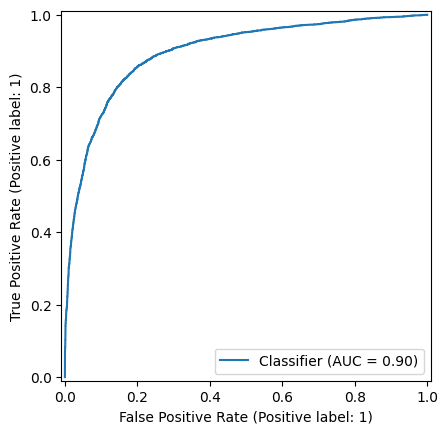

In [38]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

In [39]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipeline,
    x,
    y,
    cv=5,
    scoring='roc_auc'
)


print(scores)
print(scores.mean())

[0.89463751 0.89522949 0.8912988  0.89056796 0.88951212]
0.8922491752049574


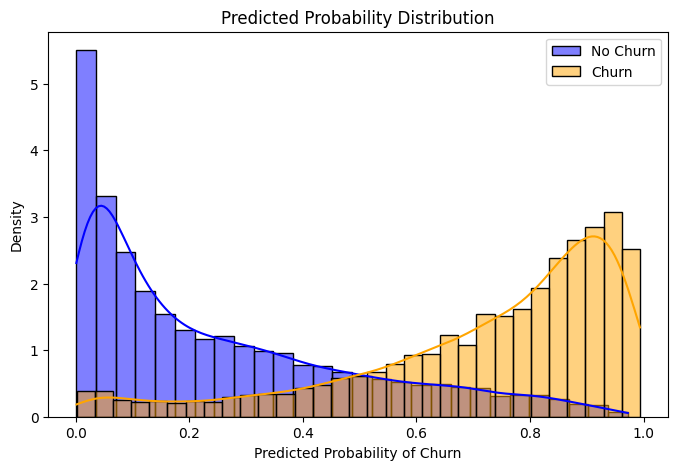

In [40]:
# probability prediction
y_prob = pipeline.predict_proba(x_test)[:,1]

# plot
plt.figure(figsize=(8,5))

sns.histplot(
    y_prob[y_test == 0],
    color='blue',
    label='No Churn',
    kde=True,
    stat='density'
)

sns.histplot(
    y_prob[y_test == 1],
    color='orange',
    label='Churn',
    kde=True,
    stat='density'
)

plt.title('Predicted Probability Distribution')

plt.xlabel('Predicted Probability of Churn')

plt.ylabel('Density')

plt.legend()

plt.show()

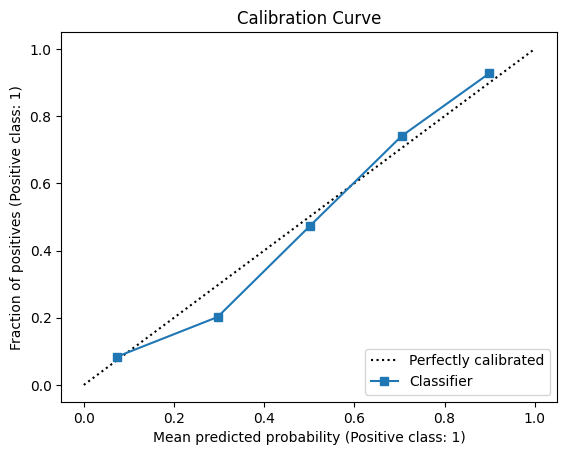

In [41]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title('Calibration Curve')

plt.show()

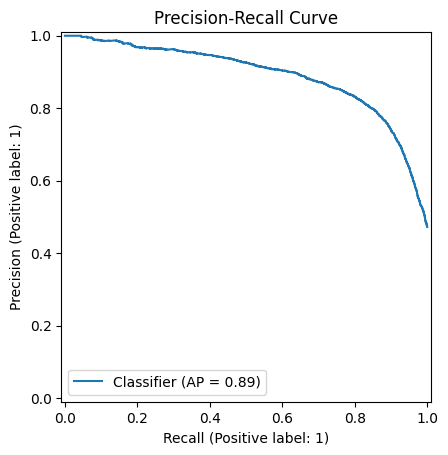

In [42]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title('Precision-Recall Curve')

plt.show()

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# probability
y_prob = pipeline.predict_proba(x_test)[:,1]

# thresholds
thresholds = np.arange(0.1, 1.0, 0.1)

results = []

for threshold in thresholds:

    # convert probability to class
    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    # metrics
    accuracy = accuracy_score(
        y_test,
        y_pred_threshold
    )

    precision = precision_score(
        y_test,
        y_pred_threshold
    )

    recall = recall_score(
        y_test,
        y_pred_threshold
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold
    )

    results.append({

        'Threshold': threshold,

        'Accuracy': accuracy,

        'Precision': precision,

        'Recall': recall,

        'F1 Score': f1
    })

# dataframe
threshold_df = pd.DataFrame(results)

print(threshold_df)

   Threshold  Accuracy  Precision    Recall  F1 Score
0        0.1  0.657165   0.582672  0.966458  0.727025
1        0.2  0.732893   0.649474  0.944097  0.769550
2        0.3  0.782369   0.708016  0.917790  0.799370
3        0.4  0.816932   0.765125  0.883755  0.820172
4        0.5  0.828427   0.810984  0.830319  0.820538
5        0.6  0.823612   0.853197  0.756823  0.802126
6        0.7  0.797049   0.891800  0.649129  0.751356
7        0.8  0.743845   0.926994  0.496876  0.646971
8        0.9  0.647301   0.964997  0.262907  0.413232


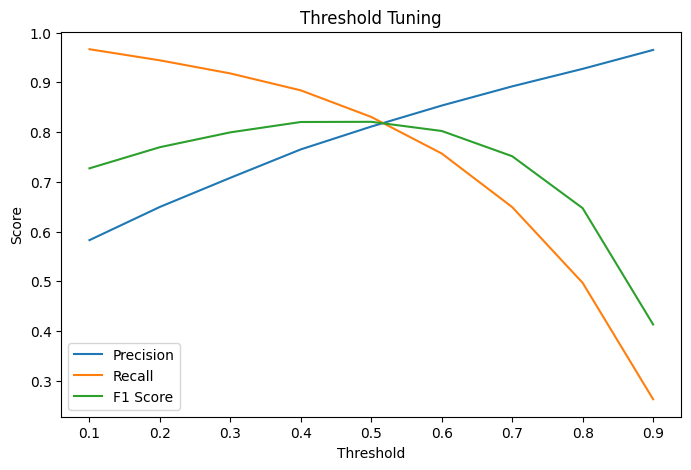

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    label='Precision'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    label='Recall'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1 Score'],
    label='F1 Score'
)

plt.xlabel('Threshold')

plt.ylabel('Score')

plt.title('Threshold Tuning')

plt.legend()

plt.show()

c:\Users\Mohd Zuhairi\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


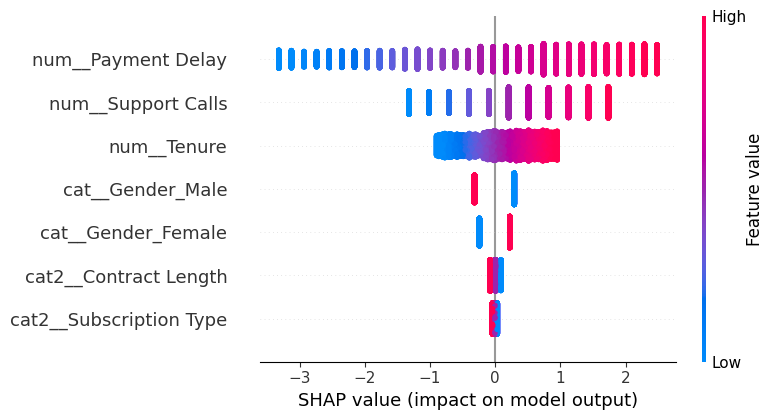

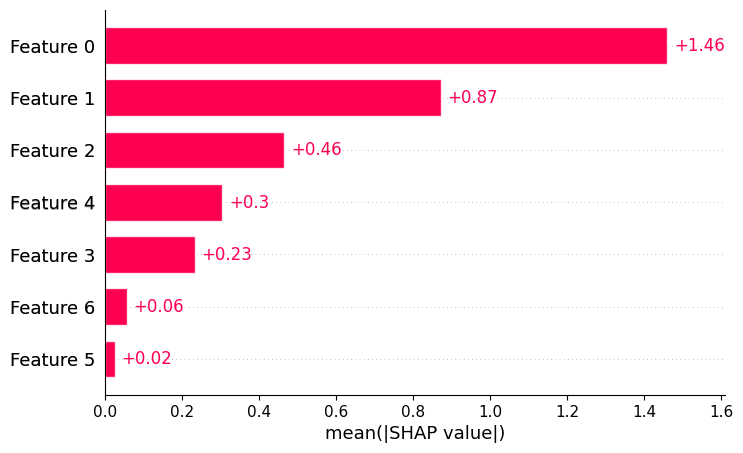

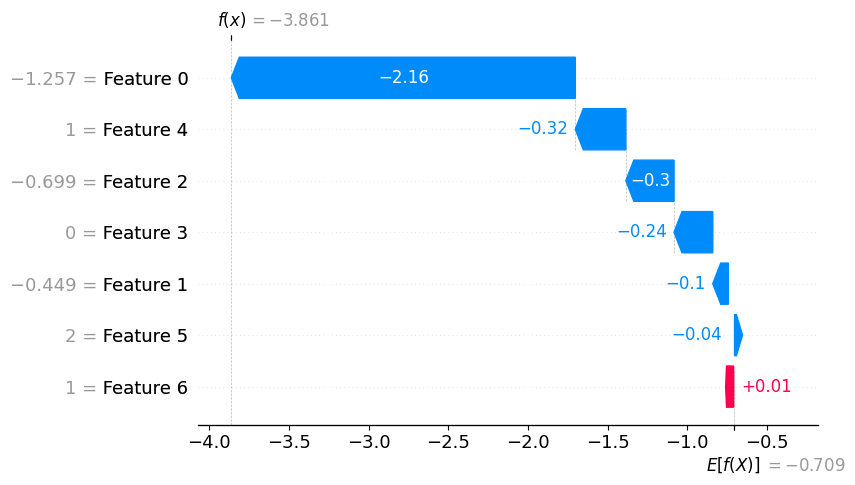

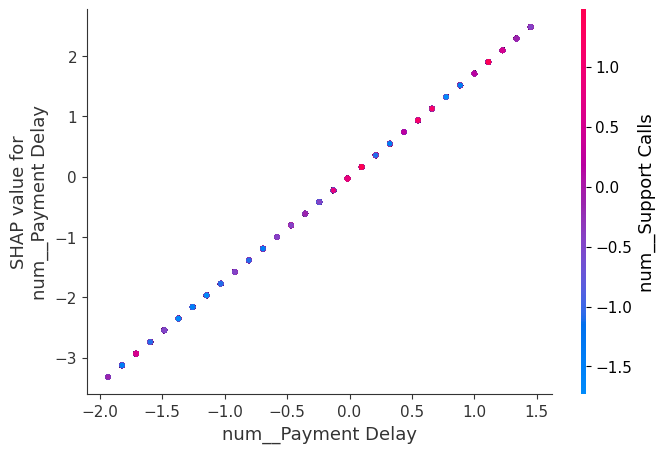

In [45]:
# =========================================================
# INSTALL SHAP
# =========================================================
# RUN IN TERMINAL FIRST:
# pip install shap

# =========================================================
# IMPORT LIBRARIES
# =========================================================
import shap

# =========================================================
# GET PREPROCESSOR
# =========================================================
preprocessors = pipeline.named_steps['preprocessor']

# =========================================================
# TRANSFORM TEST DATA
# =========================================================
x_test_transformed = preprocessors.transform(x_test)

# =========================================================
# GET TRAINED MODEL
# =========================================================
model = pipeline.named_steps['model']

# =========================================================
# GET FEATURE NAMES
# =========================================================
feature_names = preprocessors.get_feature_names_out()

# =========================================================
# CREATE SHAP EXPLAINER
# =========================================================
explainer = shap.Explainer(
    model,
    x_test_transformed
)

# =========================================================
# CALCULATE SHAP VALUES
# =========================================================
shap_values = explainer(
    x_test_transformed
)

# =========================================================
# SHAP SUMMARY PLOT
# =========================================================
shap.summary_plot(
    shap_values,
    x_test_transformed,
    feature_names=feature_names
)

# =========================================================
# SHAP BAR PLOT (FEATURE IMPORTANCE)
# =========================================================
shap.plots.bar(shap_values)

# =========================================================
# WATERFALL PLOT (INDIVIDUAL PREDICTION)
# =========================================================
# CHANGE INDEX NUMBER TO SEE OTHER CUSTOMERS

shap.plots.waterfall(
    shap_values[0]
)

# =========================================================
# FORCE PLOT
# =========================================================
# INTERACTIVE VISUALIZATION

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values.values[0],
    feature_names=feature_names
)

# =========================================================
# DEPENDENCE PLOT
# =========================================================
# SEE EFFECT OF SPECIFIC FEATURE

shap.dependence_plot(
    'num__Payment Delay',
    shap_values.values,
    x_test_transformed,
    feature_names=feature_names
)

In [46]:
sample_customer = pd.DataFrame({

    'Payment Delay': [25],
    'Support Calls': [8],
    'Tenure': [50],

    'Gender': ['Female'],
    'Subscription Type': ['Basic'],
    'Contract Length': ['Monthly']
})


prediction = pipeline.predict(sample_customer)

probability = pipeline.predict_proba(sample_customer)

print('Prediction:', prediction)

print('Probability:', probability)

Prediction: [1]
Probability: [[0.04215902 0.95784098]]


In [47]:
import joblib

joblib.dump(
    pipeline,
    'churn_model_v2.pkl'
)

print('Model resaved successfully')

Model resaved successfully


In [49]:
loaded_model = joblib.load(
    'churn_model_v2.pkl'
)

In [50]:
loaded_model.predict(sample_customer)

array([1])

In [51]:
import sklearn

print(sklearn.__version__)

1.8.0


In [52]:
x.head()

,Payment Delay,Support Calls,Tenure,Gender,Subscription Type,Contract Length
0,27,4,25,Female,Basic,Monthly
1,13,7,28,Female,Standard,Monthly
2,29,2,27,Male,Premium,Annual
3,17,5,9,Male,Premium,Quarterly
4,2,9,58,Female,Standard,Annual


In [ ]:
df.describe(include='object')

C:\Users\Mohd Zuhairi\AppData\Local\Temp\ipykernel_21188\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Gender,Subscription Type,Contract Length
count,64374,64374,64374
unique,2,3,3
top,Female,Standard,Monthly
freq,34353,21502,22130


In [53]:
import sys

print(sys.executable)

c:\Users\Mohd Zuhairi\AppData\Local\Programs\Python\Python312\python.exe


In [ ]:
{
  "Payment Delay": 25,
  "Support Calls": 8,
  "Tenure": 50,
  "Gender": "Female",
  "Subscription Type": "Basic",
  "Contract Length": "Monthly"
}